**Нейронная сеть прямого распространения для регрессии** - это многослойная архитектура, где сигнал движется от входного слоя через скрытые слои к выходному нейрону, предсказывающему непрерывное числовое значение. Каждый слой вычисляет взвешенную сумму входов и применяет нелинейную функцию активации ReLU. Обучение происходит методом обратного распространения ошибки с оптимизатором Adam, минимизирующим среднеквадратичную ошибку между предсказанными и истинными значениями.



## Используемые библиотеки



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Используемый датасет


ИНФОРМАЦИЯ О ДАТАСЕТЕ CALIFORNIA HOUSING:
Размер матрицы признаков: (20640, 8)
Количество примеров: 20640
Количество признаков: 8
Названия признаков: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Целевая переменная: MedHouseVal

ОПИСАНИЕ ПРИЗНАКОВ:
- MedInc: медианный доход жителей района
- HouseAge: медианный возраст домов в районе
- AveRooms: среднее количество комнат в доме
- AveBedrms: среднее количество спален в доме
- Population: население района
- AveOccup: средняя заселенность домов
- Latitude: широта
- Longitude: долгота

Первые 10 строк датасета:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252   41.0000    6.9841     1.0238    322.0000    2.5556   37.8800   
1  8.3014   21.0000    6.2381     0.9719   2401.0000    2.1098   37.8600   
2  7.2574   52.0000    8.2881     1.0734    496.0000    2.8023   37.8500   
3  5.6431   52.0000    5.8174     1.0731    558.0000    2.5479   37.8500   
4  

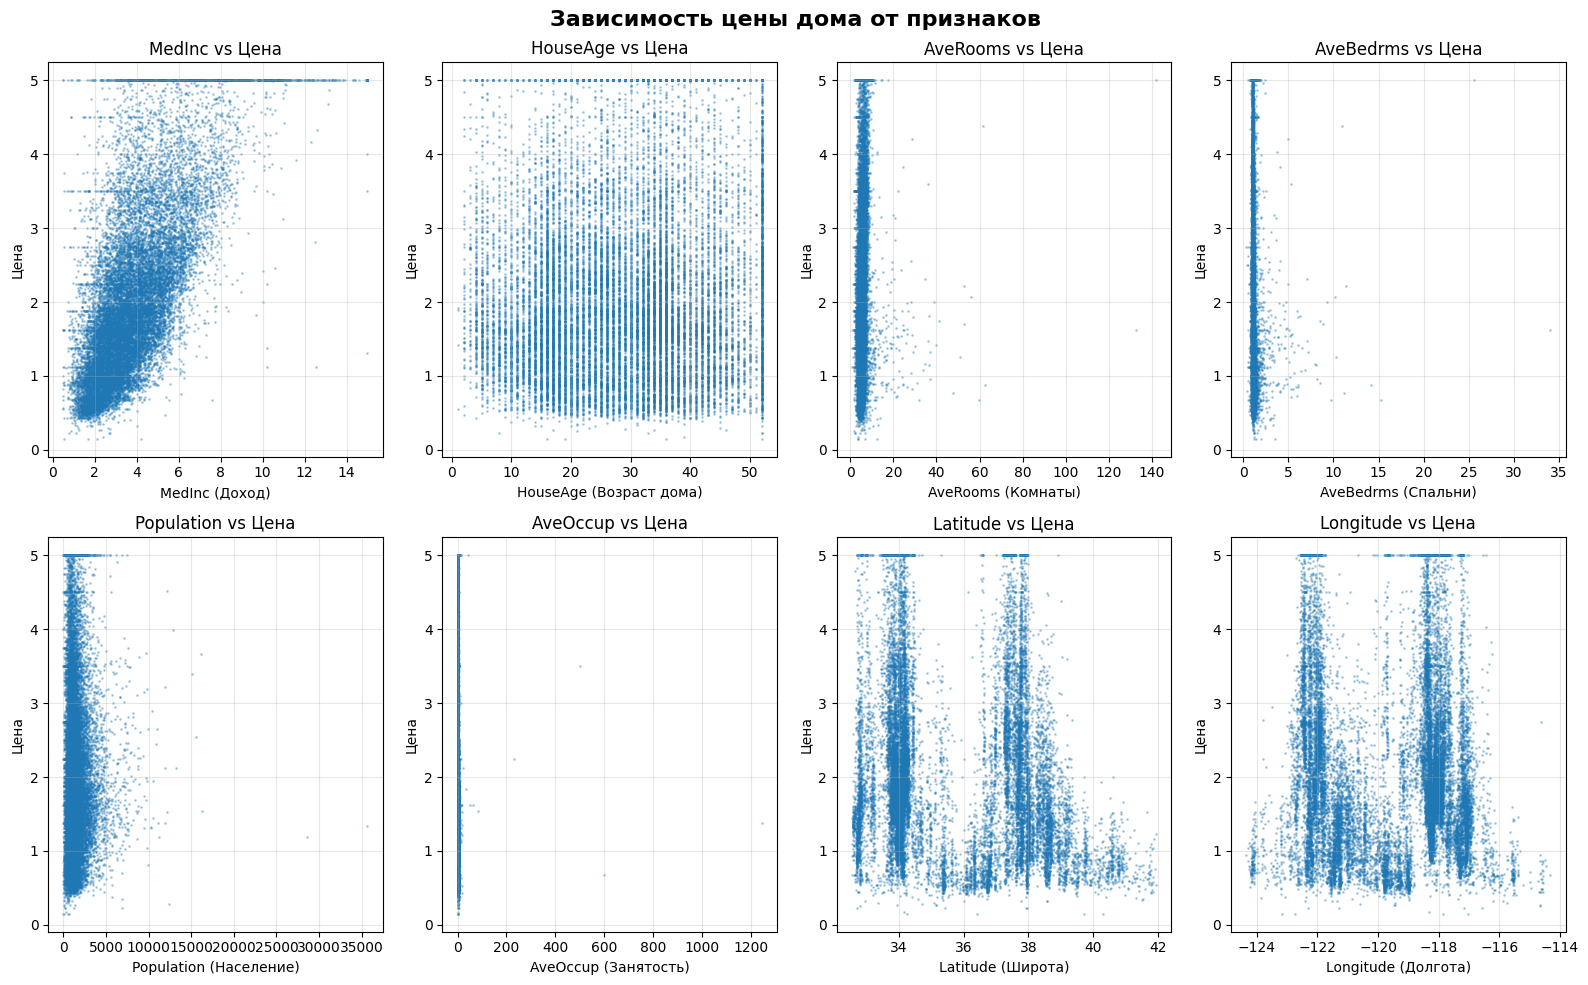

In [ ]:
housing = fetch_california_housing()
X, y = housing.data, housing.target

print("\nИНФОРМАЦИЯ О ДАТАСЕТЕ CALIFORNIA HOUSING:")
print(f"Размер матрицы признаков: {X.shape}")
print(f"Количество примеров: {len(X)}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Названия признаков: {housing.feature_names}")
print(f"Целевая переменная: {housing.target_names[0]}")
print("\nОПИСАНИЕ ПРИЗНАКОВ:")
print("- MedInc: медианный доход жителей района")
print("- HouseAge: медианный возраст домов в районе")
print("- AveRooms: среднее количество комнат в доме")
print("- AveBedrms: среднее количество спален в доме")
print("- Population: население района")
print("- AveOccup: средняя заселенность домов")
print("- Latitude: широта")
print("- Longitude: долгота")

print("\nПервые 10 строк датасета:")
df_display = pd.DataFrame(X, columns=housing.feature_names)
df_display['Price'] = y
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_display.head(10))

print("\nСТАТИСТИЧЕСКОЕ ОПИСАНИЕ ПРИЗНАКОВ:")
print(df_display.describe())
print()

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                 'Population', 'AveOccup', 'Latitude', 'Longitude']
feature_labels = ['Доход', 'Возраст дома', 'Комнаты', 'Спальни',
                  'Население', 'Занятость', 'Широта', 'Долгота']

for i in range(8):
    axes[i].scatter(X[:, i], y, alpha=0.3, s=1)
    axes[i].set_xlabel(f'{feature_names[i]} ({feature_labels[i]})')
    axes[i].set_ylabel('Цена')
    axes[i].set_title(f'{feature_names[i]} vs Цена')
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Зависимость цены дома от признаков", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Обработка датасета


РАЗДЕЛЕНИЕ ДАННЫХ:
Обучающая выборка: 16512 примеров (80.0%)
Тестовая выборка: 4128 примеров (20.0%)


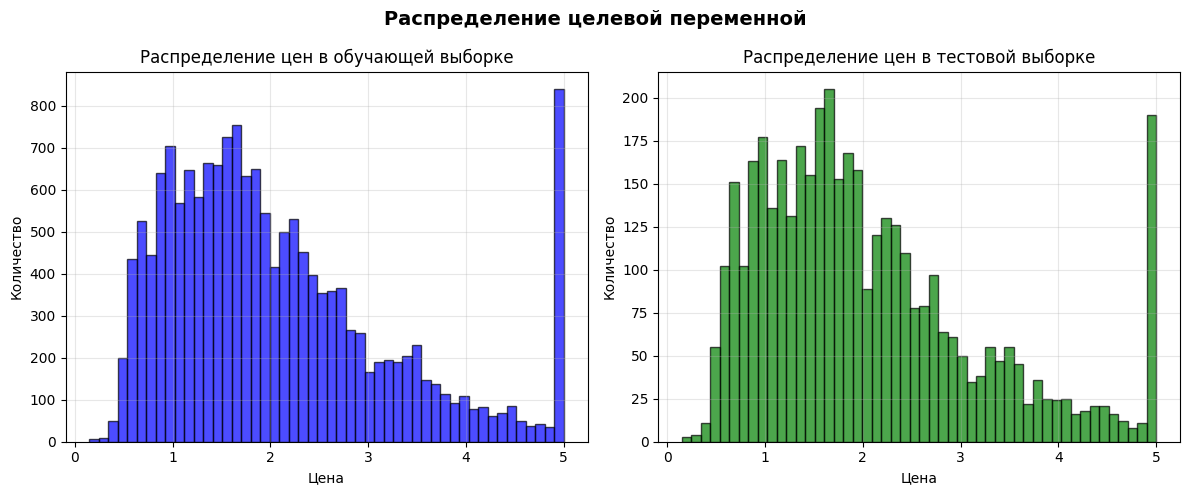

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nРАЗДЕЛЕНИЕ ДАННЫХ:")
print(f"Обучающая выборка: {X_train.shape[0]} примеров ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} примеров ({X_test.shape[0]/len(X)*100:.1f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, edgecolor='black', alpha=0.7, color='blue')
plt.title('Распределение цен в обучающей выборке')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.title('Распределение цен в тестовой выборке')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.grid(alpha=0.3)

plt.suptitle("Распределение целевой переменной", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print()

## Тепловая карта

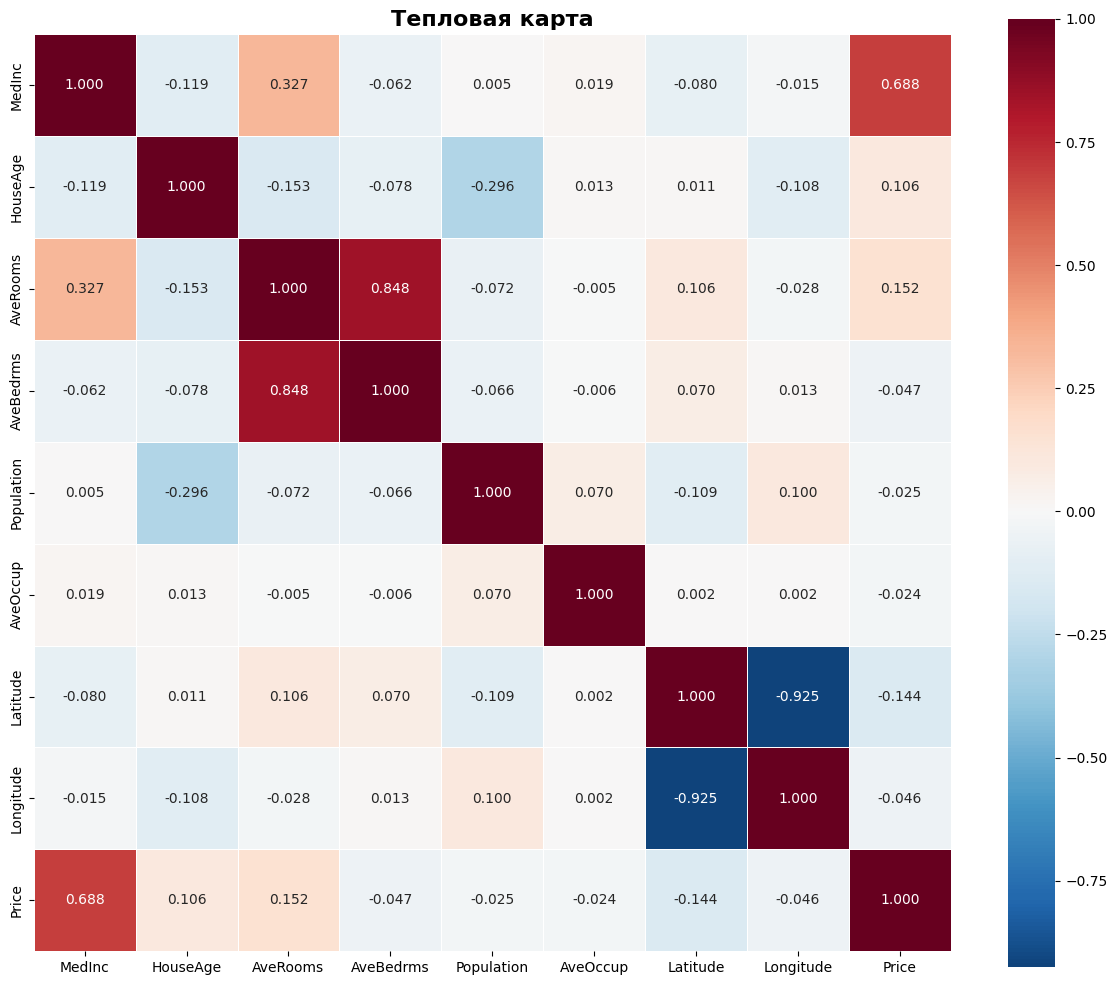

In [ ]:
plt.figure(figsize=(12, 10))

df_corr = pd.DataFrame(X, columns=housing.feature_names)
df_corr['Price'] = y

correlation_matrix = df_corr.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            square=True)

plt.title("Тепловая карта", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Обучение модели


ПРОЦЕСС ОБУЧЕНИЯ:
Iteration 1, loss = 0.87171195
Validation score: 0.563264
Iteration 2, loss = 0.25555046
Validation score: 0.680023
Iteration 3, loss = 0.20941829
Validation score: 0.724274
Iteration 4, loss = 0.19463565
Validation score: 0.738259
Iteration 5, loss = 0.18404674
Validation score: 0.725419
Iteration 6, loss = 0.17856369
Validation score: 0.751651
Iteration 7, loss = 0.17384713
Validation score: 0.753920
Iteration 8, loss = 0.16921204
Validation score: 0.768019
Iteration 9, loss = 0.16396641
Validation score: 0.771447
Iteration 10, loss = 0.16000076
Validation score: 0.772006
Iteration 11, loss = 0.15752809
Validation score: 0.776546
Iteration 12, loss = 0.15696965
Validation score: 0.778234
Iteration 13, loss = 0.15387726
Validation score: 0.785222
Iteration 14, loss = 0.15072214
Validation score: 0.783822
Iteration 15, loss = 0.14959717
Validation score: 0.784310
Iteration 16, loss = 0.14972141
Validation score: 0.787403
Iteration 17, loss = 0.14651739
Validation sco

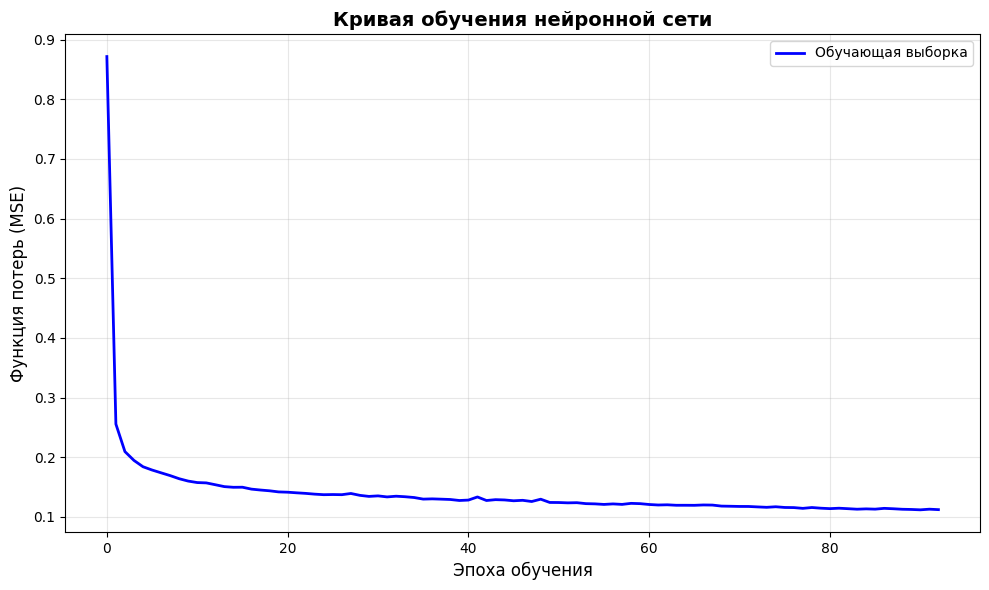

In [ ]:
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size='auto',
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

print("\nПРОЦЕСС ОБУЧЕНИЯ:")
mlp_regressor.fit(X_train_scaled, y_train)

print("-" * 50)
print("\nРЕЗУЛЬТАТЫ ОБУЧЕНИЯ:")
print(f"Количество выполненных эпох: {mlp_regressor.n_iter_}")
print(f"Финальное значение функции потерь: {mlp_regressor.loss_:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(mlp_regressor.loss_curve_, 'b-', linewidth=2, label='Обучающая выборка')
plt.xlabel('Эпоха обучения', fontsize=12)
plt.ylabel('Функция потерь (MSE)', fontsize=12)
plt.title('Кривая обучения нейронной сети', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Прогнозы модели

In [ ]:
mlp_predictions = mlp_regressor.predict(X_test_scaled)

mlp_mse = mean_squared_error(y_test, mlp_predictions)
mlp_mae = mean_absolute_error(y_test, mlp_predictions)
mlp_r2 = r2_score(y_test, mlp_predictions)

print("\nПЕРВЫЕ 10 ПРИМЕРОВ ПРЕДСКАЗАНИЙ:")
print("-" * 70)
print(f"{'№':<5} {'Истинное значение':<20} {'Предсказанное значение':<20} {'Ошибка':<15}")
print("-" * 70)
for i in range(10):
    error = y_test[i] - mlp_predictions[i]
    print(f"{i+1:<5} {y_test[i]:<20.4f} {mlp_predictions[i]:<20.4f} {error:<15.4f}")
print("-" * 70)

print("\nМЕТРИКИ КАЧЕСТВА НЕЙРОННОЙ СЕТИ:")
print("-" * 50)
print(f"{'MSE (Среднеквадратичная ошибка):':<40} {mlp_mse:.6f}")
print(f"{'MAE (Средняя абсолютная ошибка):':<40} {mlp_mae:.6f}")
print(f"{'R²:':<40} {mlp_r2:.6f}")


ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10):
----------------------------------------------------------------------
№     Истинное значение    Предсказанное значение Ошибка         
----------------------------------------------------------------------
1     0.4770               0.5179               -0.0409        
2     0.4580               1.0949               -0.6369        
3     5.0000               5.0966               -0.0965        
4     2.1860               2.4951               -0.3091        
5     2.7800               2.9002               -0.1202        
6     1.5870               1.6931               -0.1061        
7     1.9820               2.2775               -0.2955        
8     1.5750               1.5528               0.0222         
9     3.4000               2.4541               0.9459         
10    4.4660               4.6043               -0.1383        
----------------------------------------------------------------------

МЕТРИКИ КАЧЕСТВА НЕЙРОННОЙ СЕТИ:
------------

## Графики выходных результатов

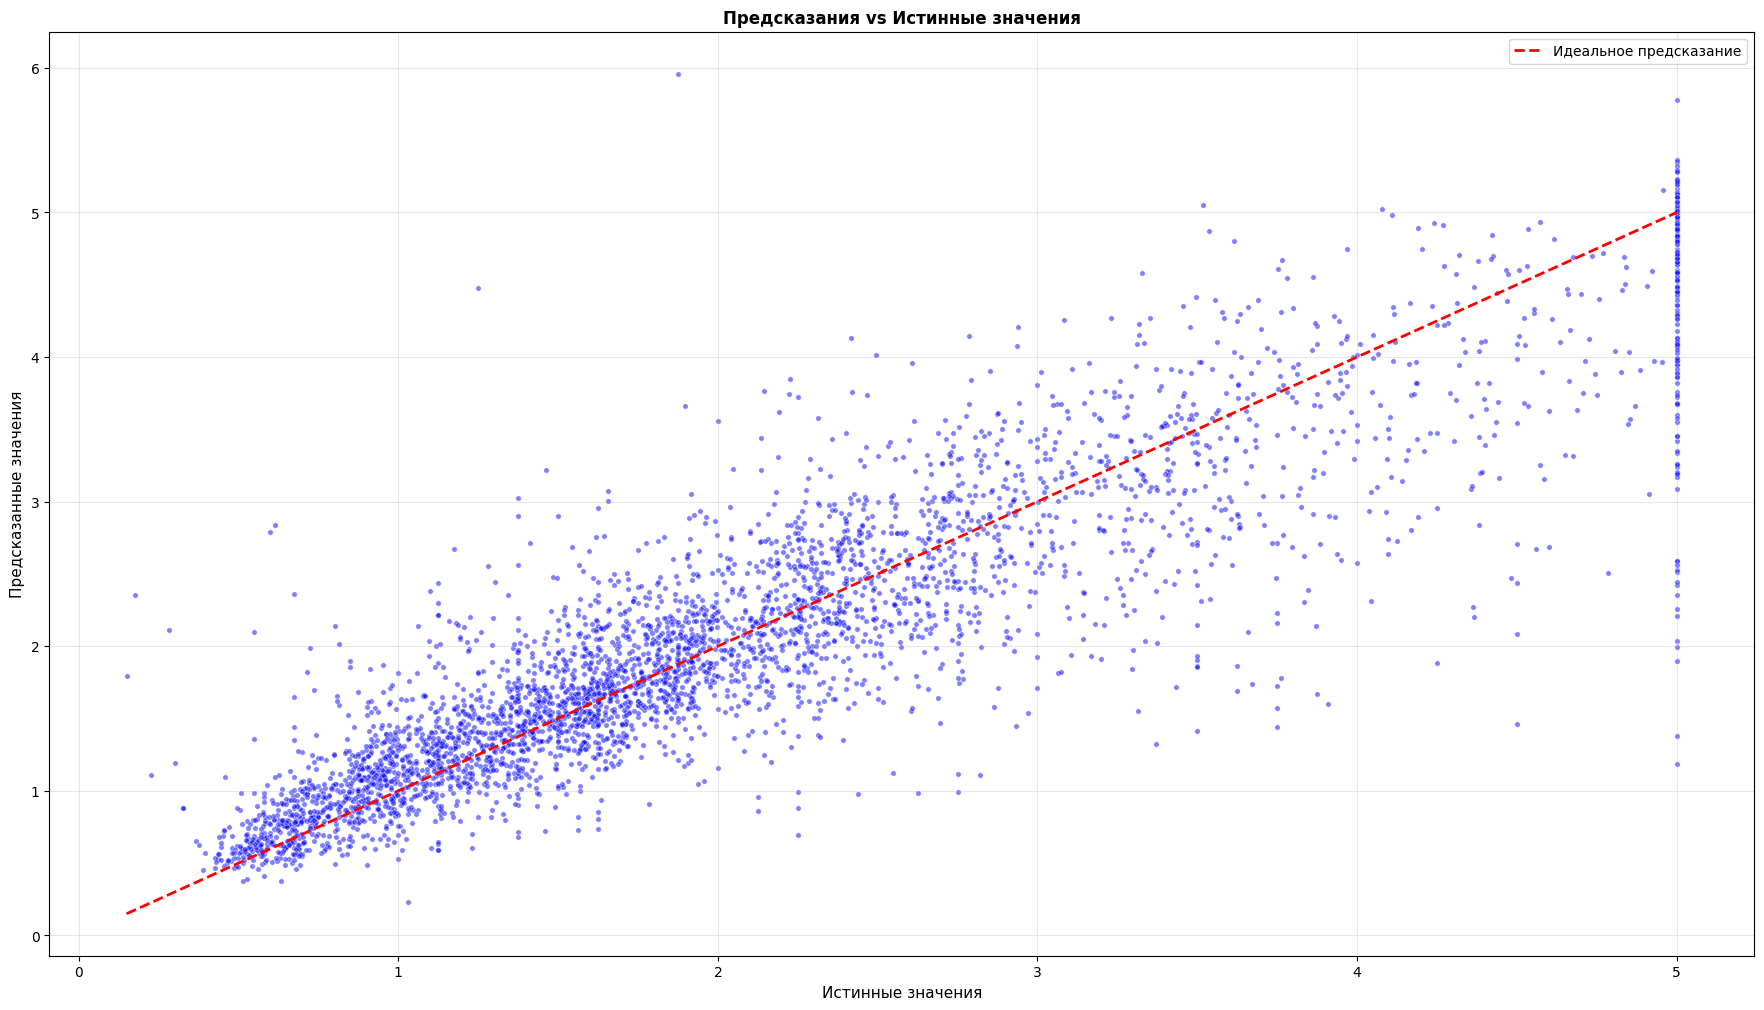

In [ ]:
fig = plt.figure(figsize=(22, 12))

ax1 = plt.subplot(1, 1, 1)
scatter = ax1.scatter(y_test, mlp_predictions, alpha=0.5, c='blue', s=15, edgecolors='white', linewidth=0.5)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Идеальное предсказание')
ax1.set_xlabel('Истинные значения', fontsize=11)
ax1.set_ylabel('Предсказанные значения', fontsize=11)
ax1.set_title('Предсказания vs Истинные значения', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)